In [1]:
# Importando e configurando o Pandas
import pandas as pd


In [2]:
# Importando o dataset
url = 'https://raw.githubusercontent.com/bluenex/WekaLearningDataset/master/bank/bank-data.csv'
df = pd.read_csv(url)
df.head()

,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48,FEMALE,INNER_CITY,17546.0,NO,1,NO,NO,NO,NO,YES
1,ID12102,40,MALE,TOWN,30085.1,YES,3,YES,NO,YES,YES,NO
2,ID12103,51,FEMALE,INNER_CITY,16575.4,YES,0,YES,YES,YES,NO,NO
3,ID12104,23,FEMALE,TOWN,20375.4,YES,3,NO,NO,YES,NO,NO
4,ID12105,57,FEMALE,RURAL,50576.3,YES,0,NO,YES,NO,NO,NO


In [3]:
# Exibir o percentual de cada classe categórica
print(df['sex'].value_counts(normalize=True) * 100)
print('---');
print(df['region'].value_counts(normalize=True) * 100)

sex
FEMALE    50.0
MALE      50.0
Name: proportion, dtype: float64
---
region
INNER_CITY    44.833333
TOWN          28.833333
RURAL         16.000000
SUBURBAN      10.333333
Name: proportion, dtype: float64


In [4]:
#Substituindo as variáveis categóricas com pesos para classes mais frequentes

df['sex'] = df['sex'].replace('MALE', 0)
df['sex'] = df['sex'].replace('FEMALE', 1)

df['region'] = df['region'].replace('INNER_CITY', 3)
df['region'] = df['region'].replace('TOWN', 2)
df['region'] = df['region'].replace('RURAL', 1)
df['region'] = df['region'].replace('SUBURBAN', 0)

/tmp/ipykernel_11420/107028385.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace('FEMALE', 1)
/tmp/ipykernel_11420/107028385.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['region'] = df['region'].replace('SUBURBAN', 0)


In [5]:
pd.set_option('future.no_silent_downcasting', True) #Definindo comportamento do Pandas

In [6]:
# Converter colunas para o formato one_hot_encoding
columns_to_convert = ['married', 'car', 'save_act', 'current_act', 'mortgage', 'pep']

# Substituir vírgulas por pontos antes de converter
for column in columns_to_convert:
    df[column] = df[column].replace('NO', 0)
    df[column] = df[column].replace('YES', 1)

In [7]:
df.head()

,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48,1,3,17546.0,0,1,0,0,0,0,1
1,ID12102,40,0,2,30085.1,1,3,1,0,1,1,0
2,ID12103,51,1,3,16575.4,1,0,1,1,1,0,0
3,ID12104,23,1,2,20375.4,1,3,0,0,1,0,0
4,ID12105,57,1,1,50576.3,1,0,0,1,0,0,0


In [8]:
#Removendo a coluna 'id' para não interferir nos cálculos
df = df.drop(['id'], axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          600 non-null    int64  
 1   sex          600 non-null    int64  
 2   region       600 non-null    int64  
 3   income       600 non-null    float64
 4   married      600 non-null    object 
 5   children     600 non-null    int64  
 6   car          600 non-null    object 
 7   save_act     600 non-null    object 
 8   current_act  600 non-null    object 
 9   mortgage     600 non-null    object 
 10  pep          600 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 51.7+ KB


In [10]:
# prompt: converta as variáveis do tipo object para int
#  0   age          600 non-null    int64
#  1   sex          600 non-null    int64
#  2   region       600 non-null    int64
#  3   income       600 non-null    float64
#  4   married      600 non-null    object
#  5   children     600 non-null    int64
#  6   car          600 non-null    object
#  7   save_act     600 non-null    object
#  8   current_act  600 non-null    object
#  9   mortgage     600 non-null    object
#  10  pep          600 non-null    object

# Convertendo colunas object para int
for col in ['married', 'car', 'save_act', 'current_act', 'mortgage', 'pep']:
    df[col] = df[col].astype(int)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          600 non-null    int64  
 1   sex          600 non-null    int64  
 2   region       600 non-null    int64  
 3   income       600 non-null    float64
 4   married      600 non-null    int64  
 5   children     600 non-null    int64  
 6   car          600 non-null    int64  
 7   save_act     600 non-null    int64  
 8   current_act  600 non-null    int64  
 9   mortgage     600 non-null    int64  
 10  pep          600 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 51.7 KB


In [11]:
df.describe()

,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,42.395000,0.500000,2.081667,27524.031217,0.660000,1.011667,0.493333,0.690000,0.758333,0.348333,0.456667
std,14.424947,0.500417,1.008311,12899.468246,0.474104,1.056752,0.500373,0.462879,0.428451,0.476840,0.498534
min,18.000000,0.000000,0.000000,5014.210000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,1.000000,17264.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,42.000000,0.500000,2.000000,24925.300000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,55.250000,1.000000,3.000000,36172.675000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,67.000000,1.000000,3.000000,63130.100000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# Criar a coluna de salário anual escalado
df['scaled_income'] = df['income'] / 1000

In [13]:
# Criar a coluna de renda per capita
df['per_capita_income'] = df['income'] / (1 + df['married'] + df['children'])

In [14]:
# Criar a coluna de renda per capita anual escalada
df['scaled_per_capita_income'] = df['per_capita_income'] / 1000

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Criar um novo DataFrame excluindo variáveis que podem causar padrões lineares
df_new = df.drop(columns=['income', 'per_capita_income'])

# Normalizar os dados antes de aplicar clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_new[['age', 'scaled_income', 'scaled_per_capita_income']])

In [16]:
scaled_features

array([[ 0.38888715, -0.77416809, -0.42234488],
       [-0.16617033,  0.19870631, -0.72156587],
       [ 0.59703371, -0.84947428, -0.47503465],
       ...,
       [-0.79061001, -0.89595681, -0.50755725],
       [-0.92937438, -0.99406589, -0.57620161],
       [-0.30493471, -0.0661378 ,  1.52093366]])

In [17]:
import matplotlib.pyplot as plt

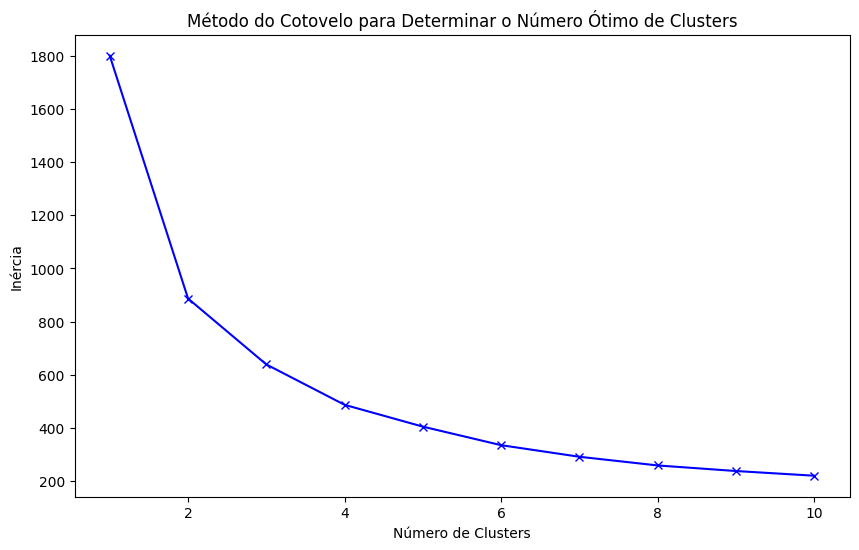

In [18]:
# Determinar o número ideal de clusters usando o gráfico do cotovelo
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Determinar o Número Ótimo de Clusters')
plt.show()

In [19]:
# Aplicar KMeans para clustering com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_new['cluster'] = kmeans.fit_predict(scaled_features)

# Exibir as primeiras linhas do dataset atualizado
print(df_new.head())

   age  sex  region  married  children  car  save_act  current_act  mortgage  \
0   48    1       3        0         1    0         0            0         0   
1   40    0       2        1         3    1         0            1         1   
2   51    1       3        1         0    1         1            1         0   
3   23    1       2        1         3    0         0            1         0   
4   57    1       1        1         0    0         1            0         0   

   pep  scaled_income  scaled_per_capita_income  cluster  
0    1        17.5460                   8.77300        0  
1    0        30.0851                   6.01702        0  
2    0        16.5754                   8.28770        0  
3    0        20.3754                   4.07508        1  
4    0        50.5763                  25.28815        2  


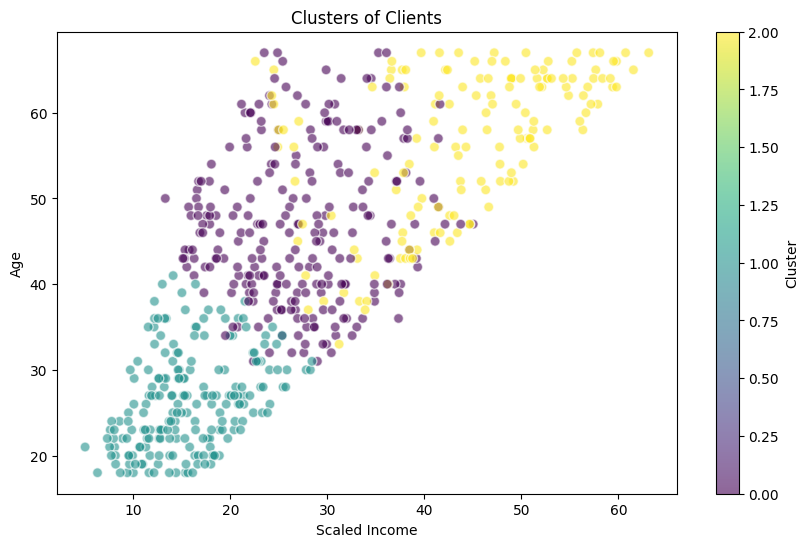

In [20]:
# Plotar os clusters
plt.figure(figsize=(10, 6))
plt.scatter(df_new['scaled_income'], df_new['age'], c=df_new['cluster'], cmap='viridis', marker='o', s=50, alpha=0.6, edgecolors='w')
plt.xlabel('Scaled Income')
plt.ylabel('Age')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

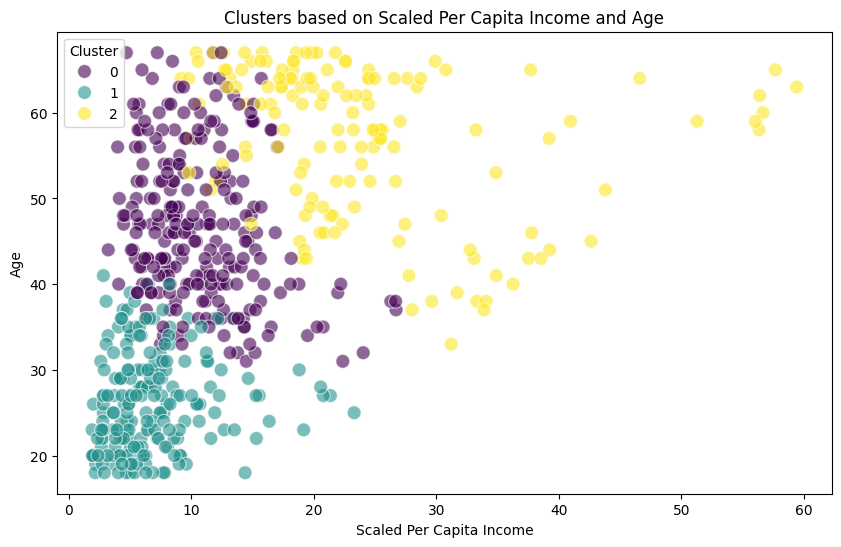

In [21]:
import seaborn as sns

# Calcular a proporção de clientes com PEP em cada cluster
pep_distribution = df_new.groupby('cluster')['pep'].mean()

# Plotar os clusters com base na renda per capita e idade
plt.figure(figsize=(10, 6))
sns.scatterplot(x='scaled_per_capita_income', y='age', hue='cluster', data=df_new, palette='viridis', s=100, alpha=0.6, edgecolor='w')
plt.xlabel('Scaled Per Capita Income')
plt.ylabel('Age')
plt.title('Clusters based on Scaled Per Capita Income and Age')
plt.legend(title='Cluster')
plt.show()

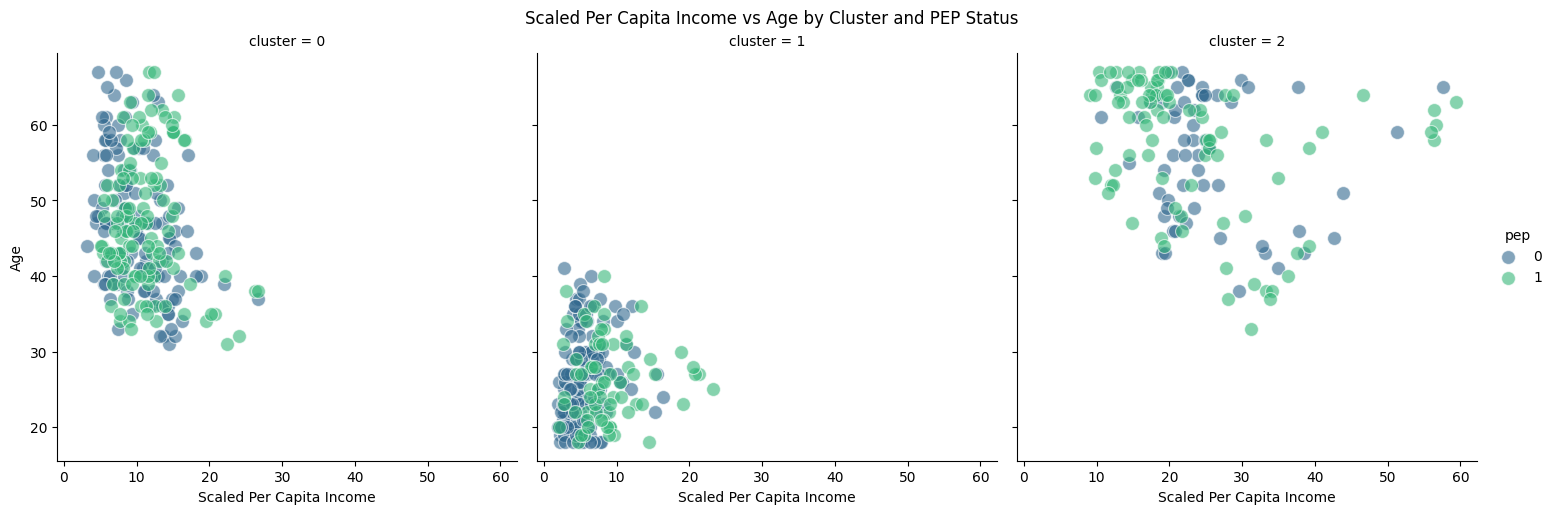

In [22]:
# Plotar a relação entre renda per capita, idade e PEP dentro de cada cluster
g = sns.FacetGrid(df_new, col="cluster", hue="pep", palette="viridis", col_wrap=3, height=5)
g.map(sns.scatterplot, "scaled_per_capita_income", "age", alpha=0.6, edgecolor="w", s=100)
g.add_legend()
g.set_axis_labels("Scaled Per Capita Income", "Age")
g.fig.suptitle("Scaled Per Capita Income vs Age by Cluster and PEP Status", y=1.02)
plt.show()

In [23]:
'''
Cluster 0
-Faixa Etária: Predominantemente jovens, entre 20 e 40 anos.
-Renda Per Capita Escalada: Principalmente abaixo de 10.
-Aquisição de PEP: A aquisição de PEP parece distribuída de forma relativamente uniforme entre clientes com e sem PEP, sem uma clara distinção baseada na renda per capita ou idade.

Cluster 1
-Faixa Etária: Clientes de idade intermediária, entre 30 e 50 anos.
-Renda Per Capita Escalada: Varia até 40, com uma concentração notável entre 10 e 30.
-Aquisição de PEP: Clientes com PEP parecem estar mais concentrados nas faixas de renda per capita mais alta (acima de 20), sugerindo que a renda per capita pode ser um fator relevante para a aquisição de PEP neste cluster.

Cluster 2
-Faixa Etária: Clientes mais velhos, geralmente acima de 50 anos.
-Renda Per Capita Escalada: Distribuição mais ampla, chegando até 60.
-Aquisição de PEP: Aquisição de PEP parece estar mais associada a rendas per capita mais altas. Clientes com PEP são mais frequentes nas faixas de renda per capita acima de 20.
'''

'\nCluster 0\n-Faixa Etária: Predominantemente jovens, entre 20 e 40 anos.\n-Renda Per Capita Escalada: Principalmente abaixo de 10.\n-Aquisição de PEP: A aquisição de PEP parece distribuída de forma relativamente uniforme entre clientes com e sem PEP, sem uma clara distinção baseada na renda per capita ou idade.\n\nCluster 1\n-Faixa Etária: Clientes de idade intermediária, entre 30 e 50 anos.\n-Renda Per Capita Escalada: Varia até 40, com uma concentração notável entre 10 e 30.\n-Aquisição de PEP: Clientes com PEP parecem estar mais concentrados nas faixas de renda per capita mais alta (acima de 20), sugerindo que a renda per capita pode ser um fator relevante para a aquisição de PEP neste cluster.\n\nCluster 2\n-Faixa Etária: Clientes mais velhos, geralmente acima de 50 anos.\n-Renda Per Capita Escalada: Distribuição mais ampla, chegando até 60.\n-Aquisição de PEP: Aquisição de PEP parece estar mais associada a rendas per capita mais altas. Clientes com PEP são mais frequentes nas fa

In [24]:
'''
Cluster 0: A relação entre a renda per capita e a aquisição de PEP não é clara, indicando que outros fatores podem influenciar a decisão de aquisição de PEP para clientes jovens com rendas per capita mais baixas.
           Poupança? Hipoteca? Sexo? Avaliar e modelar uma campanha específica.

Cluster 1: Renda per capita parece ser um fator importante para a aquisição de PEP. Clientes com rendas per capita mais altas têm maior propensão a adquirir PEP.

Cluster 2: Renda per capita elevada está associada a uma maior probabilidade de aquisição de PEP. Clientes mais velhos com estabilidade financeira têm maior tendência a adquirir PEP.
'''


# Selecionar clientes para a campanha no Cluster 1
campaign_cluster_1 = df_new[(df_new['cluster'] == 1) &
                          (df_new['scaled_per_capita_income'] > 20) &
                          (df_new['age'].between(30, 50))]

# Selecionar clientes para a campanha no Cluster 2
campaign_cluster_2 = df_new[(df_new['cluster'] == 2) &
                          (df_new['scaled_per_capita_income'] > 20) &
                          (df_new['age'] > 50)]

# Exibir os resultados
print("Clientes selecionados para a campanha no Cluster 1:")
print(campaign_cluster_1)

print("\nClientes selecionados para a campanha no Cluster 2:")
print(campaign_cluster_2)

Clientes selecionados para a campanha no Cluster 1:
Empty DataFrame
Columns: [age, sex, region, married, children, car, save_act, current_act, mortgage, pep, scaled_income, scaled_per_capita_income, cluster]
Index: []

Clientes selecionados para a campanha no Cluster 2:
     age  sex  region  married  children  car  save_act  current_act  \
4     57    1       1        1         0    0         1            0   
10    66    1       2        1         0    0         1            1   
11    52    1       3        0         0    1         1            1   
25    56    0       3        1         0    1         1            1   
54    63    0       2        1         0    0         1            1   
56    58    1       3        0         0    0         0            1   
87    66    1       2        0         0    1         1            1   
92    53    1       1        0         0    0         0            1   
94    61    1       3        1         0    1         1            0   
115   54 

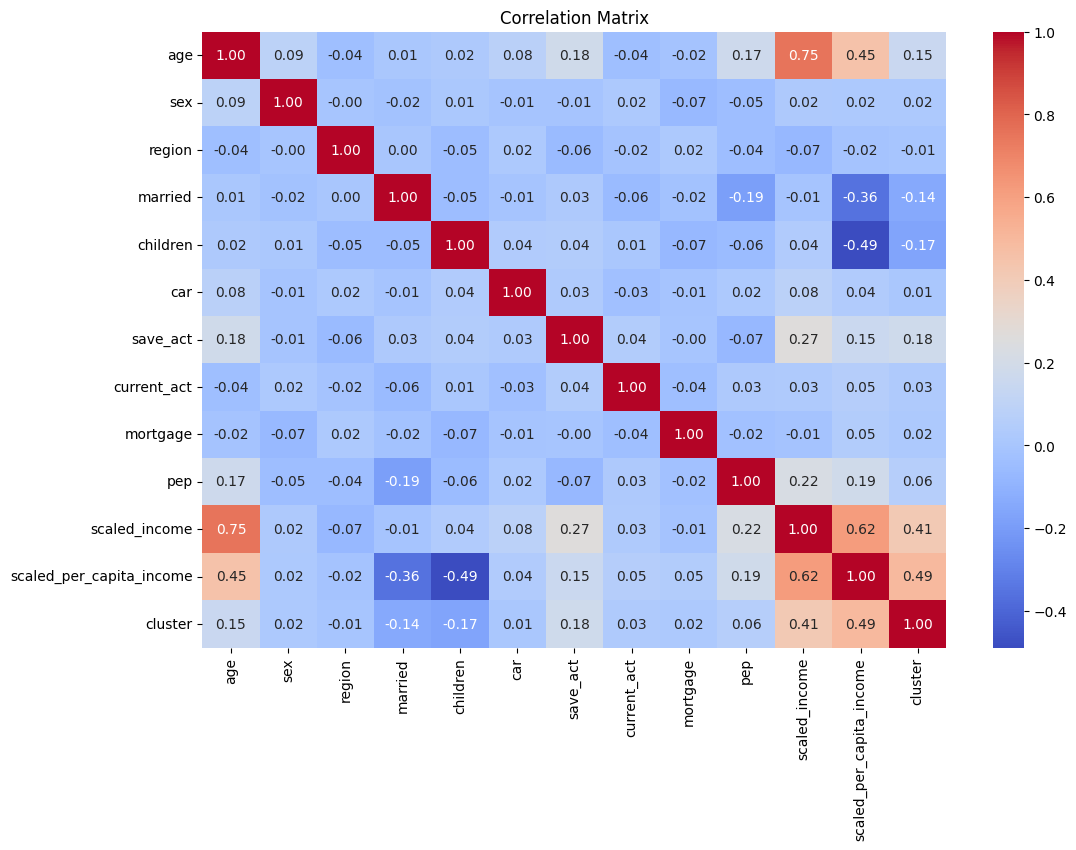

In [25]:
# Calcular a matriz de correlação
correlation_matrix = df_new.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [27]:
# Preparar os dados para a modelagem preditiva
#X = df_new[['age', 'scaled_income', 'scaled_per_capita_income', 'cluster']]

X = df_new.drop(columns=['pep'])
y = df['pep']

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

# Treinar o modelo de RandomForest
model = ExtraTreesClassifier()
model.fit(X_train, y_train)

# Prever no conjunto de teste e calcular a probabilidade de adquirir PEP
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X)[:, 1]

# Avaliar o modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88        70
           1       0.82      0.84      0.83        50

    accuracy                           0.86       120
   macro avg       0.85      0.86      0.85       120
weighted avg       0.86      0.86      0.86       120



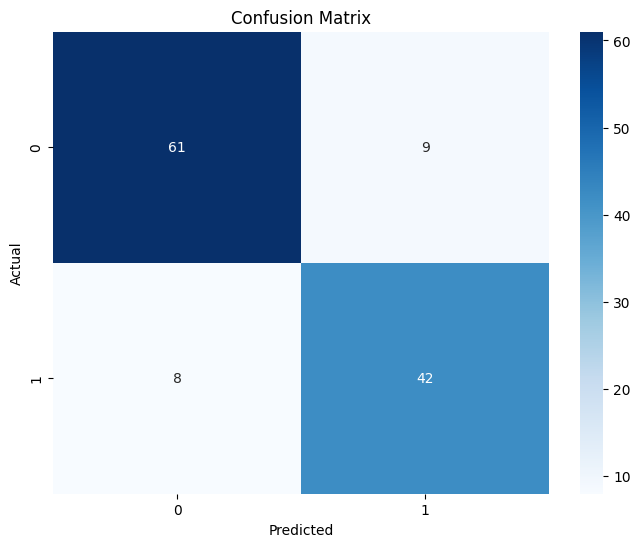

In [28]:
# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

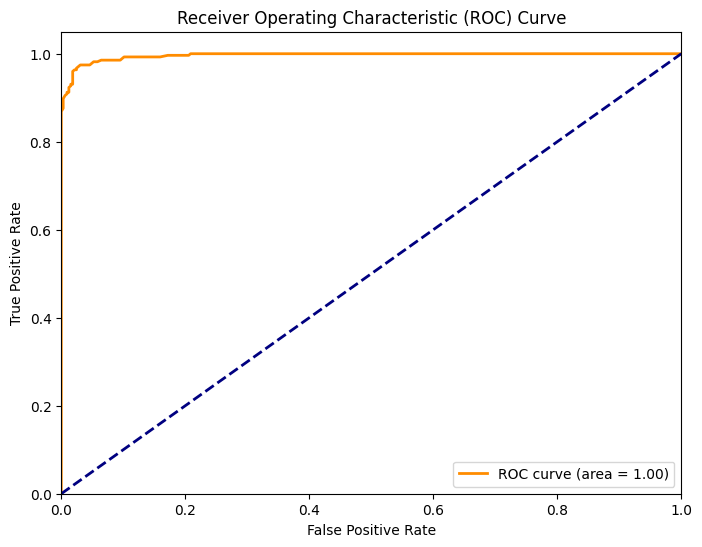

In [29]:
# Curva ROC
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [30]:
# Adicionar a coluna de probabilidade no dataset
df_campaign = df_new
df_campaign['pep_probability'] = y_pred_proba

# Selecionar clientes para a campanha no Cluster 1
campaign_cluster_1 = df_campaign[(df_campaign['cluster'] == 1) &
                          (df_campaign['scaled_per_capita_income'] > 20) &
                          (df_campaign['age'].between(30, 50))]

# Selecionar clientes para a campanha no Cluster 2
campaign_cluster_2 = df_campaign[(df_campaign['cluster'] == 2) &
                          (df_campaign['scaled_per_capita_income'] > 20) &
                          (df_campaign['age'] > 50)]

# Exibir os resultados
print("Clientes selecionados para a campanha no Cluster 1:")
print(campaign_cluster_1[['age', 'scaled_income', 'scaled_per_capita_income', 'cluster', 'pep_probability']])

print("\nClientes selecionados para a campanha no Cluster 2:")
print(campaign_cluster_2[['age', 'scaled_income', 'scaled_per_capita_income', 'cluster', 'pep_probability']])

Clientes selecionados para a campanha no Cluster 1:
Empty DataFrame
Columns: [age, scaled_income, scaled_per_capita_income, cluster, pep_probability]
Index: []

Clientes selecionados para a campanha no Cluster 2:
     age  scaled_income  scaled_per_capita_income  cluster  pep_probability
4     57        50.5763                 25.288150        2             0.00
10    66        59.8039                 29.901950        2             0.00
11    52        26.6588                 26.658800        2             0.00
25    56        41.0340                 20.517000        2             0.00
54    63        56.8425                 28.421250        2             0.00
56    58        24.9775                 24.977500        2             1.00
87    66        22.5622                 22.562200        2             0.00
92    53        34.8665                 34.866500        2             1.00
94    61        41.1274                 20.563700        2             0.28
115   54        47.7968    

In [31]:
# Selecionar clientes para a campanha no Cluster 1
campaign_cluster_1 = df_campaign[(df_campaign['cluster'] == 1) &
                          (df_campaign['pep'] == 0) &
                          (df_campaign['pep_probability'] > 0.1) &
                          (df_campaign['scaled_per_capita_income'] > 20) &
                          (df_campaign['age'].between(30, 50))].sort_values(by='pep_probability', ascending=False)

# Selecionar clientes para a campanha no Cluster 2
campaign_cluster_2 = df_campaign[(df_campaign['cluster'] == 2) &
                          (df_campaign['pep'] == 0) &
                          (df_campaign['pep_probability'] > 0) &
                          (df_campaign['scaled_per_capita_income'] > 20) &
                          (df_campaign['age'] > 50)].sort_values(by='pep_probability', ascending=False)

# Exibir os resultados
print("Clientes selecionados para a campanha no Cluster 1:")
print(campaign_cluster_1[['pep', 'pep_probability']])

print("\nClientes selecionados para a campanha no Cluster 2:")
print(campaign_cluster_2[['pep', 'pep_probability']])

Clientes selecionados para a campanha no Cluster 1:
Empty DataFrame
Columns: [pep, pep_probability]
Index: []

Clientes selecionados para a campanha no Cluster 2:
     pep  pep_probability
250    0             0.51
94     0             0.28
223    0             0.17
470    0             0.16
390    0             0.01
